# Ejercicio 12: Multimodal Embeddings

## Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

### Pasos:

1. Obtener embeddings de imágenes y textos con CLIP.
2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

Cargando modelo...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

¡Modelo cargado con éxito!


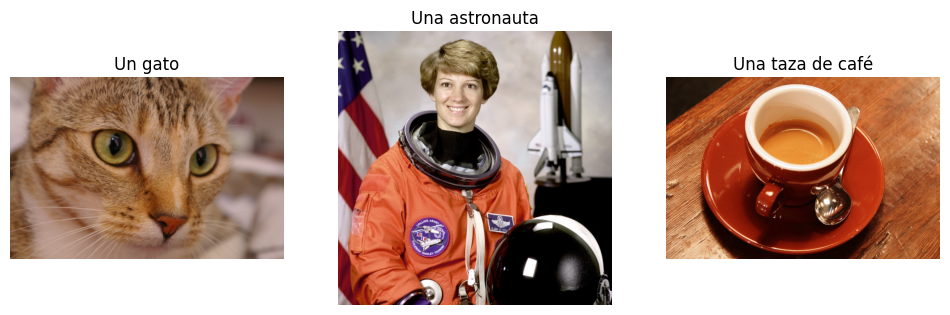

In [6]:
# Importación de librerías necesarias
import os
import warnings
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from transformers import CLIPProcessor, CLIPModel, logging
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import skimage.data  # Librería con imágenes preinstaladas localmente

# Apagar advertencias
warnings.filterwarnings("ignore")
logging.set_verbosity_error()

# 1. Clonar el repositorio usando git (o cargarlo si ya está clonado)
if not os.path.exists("./clip-local"):
    print("Clonando el modelo en el entorno de Colab...")
    !apt-get install git-lfs -y > /dev/null
    !git lfs install > /dev/null
    !git clone https://huggingface.co/openai/clip-vit-base-patch32 ./clip-local

# 2. Cargar el modelo desde la carpeta local
ruta_colab = "./clip-local"
print("Cargando modelo...")
processor = CLIPProcessor.from_pretrained(ruta_colab, local_files_only=True)
model = CLIPModel.from_pretrained(ruta_colab, local_files_only=True)
print("¡Modelo cargado con éxito!")

# 3. Usar imágenes locales de scikit-image (Cero descargas de internet)
img_cat = Image.fromarray(skimage.data.cat())
img_astronaut = Image.fromarray(skimage.data.astronaut())
img_coffee = Image.fromarray(skimage.data.coffee())

images = [img_cat, img_astronaut, img_coffee]

# 4. Definir textos que coincidan con las imágenes locales
texts = [
    "Un gato", 
    "Una astronauta", 
    "Una taza de café"
]

# Mostrar las imágenes
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for img, ax, title in zip(images, axes, texts):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')
plt.show()

### Paso 1 y 2: Extracción de Embeddings y Verificación de Espacio
Procesamos los inputs a través de CLIP. Verificaremos que los vectores resultantes, tanto de la modalidad visual como textual, compartan exactamente la misma dimensionalidad matemática.

In [7]:
# Procesar entradas (textos e imágenes)
inputs = processor(text=texts, images=images, return_tensors="pt", padding=True)

# Obtener embeddings sin calcular gradientes para ahorrar memoria
with torch.no_grad():
    outputs = model(**inputs)
    image_embeds = outputs.image_embeds
    text_embeds = outputs.text_embeds

# Normalizar los embeddings (L2 normalization) para usar similitud del coseno
image_embeds = image_embeds / image_embeds.norm(p=2, dim=-1, keepdim=True)
text_embeds = text_embeds / text_embeds.norm(p=2, dim=-1, keepdim=True)

print("--- Verificación del Espacio Vectorial ---")
print(f"Dimensión del tensor de Imágenes: {image_embeds.shape}")
print(f"Dimensión del tensor de Textos: {text_embeds.shape}")
print("Al tener la misma dimensión de características (512), viven en el mismo espacio y son directamente comparables.")

--- Verificación del Espacio Vectorial ---
Dimensión del tensor de Imágenes: torch.Size([3, 512])
Dimensión del tensor de Textos: torch.Size([3, 512])
Al tener la misma dimensión de características (512), viven en el mismo espacio y son directamente comparables.


### Paso 3: Proyección a 2D (PCA)
Para visualizar un espacio de 512 dimensiones en un plano cartesiano, aplicaremos Análisis de Componentes Principales (PCA). Graficaremos los textos y las imágenes para observar cómo los conceptos semánticamente similares se agrupan.

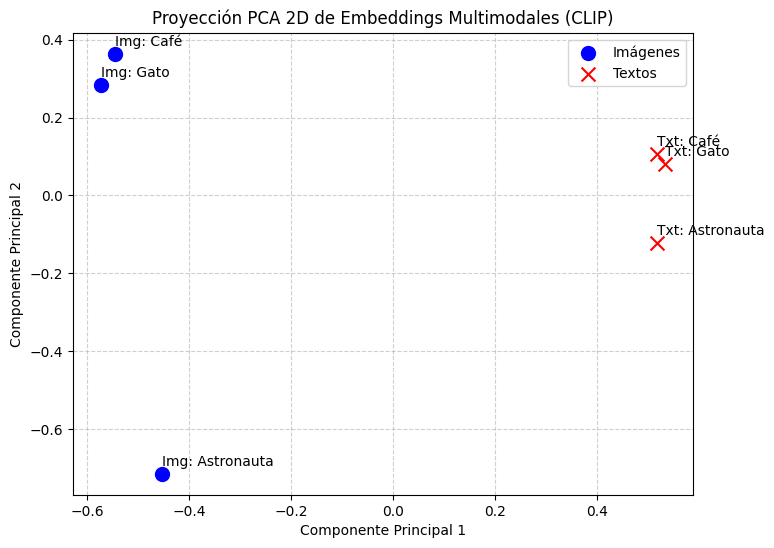

In [8]:
# Concatenar todos los vectores para reducir su dimensionalidad juntos
all_embeds = torch.cat([image_embeds, text_embeds]).numpy()

# Reducir a 2 dimensiones usando PCA
pca = PCA(n_components=2)
embeds_2d = pca.fit_transform(all_embeds)

# Separar de nuevo los vectores 2D
image_embeds_2d = embeds_2d[:3]
text_embeds_2d = embeds_2d[3:]

# Graficar
plt.figure(figsize=(8, 6))

# Plot imágenes
plt.scatter(image_embeds_2d[:, 0], image_embeds_2d[:, 1], c='blue', marker='o', s=100, label='Imágenes')
# Plot textos
plt.scatter(text_embeds_2d[:, 0], text_embeds_2d[:, 1], c='red', marker='x', s=100, label='Textos')

# Añadir etiquetas a los puntos actualizadas
labels = ["Gato", "Astronauta", "Café"]
for i, label in enumerate(labels):
    plt.annotate(f"Img: {label}", (image_embeds_2d[i, 0], image_embeds_2d[i, 1] + 0.02))
    plt.annotate(f"Txt: {label}", (text_embeds_2d[i, 0], text_embeds_2d[i, 1] + 0.02))

plt.title("Proyección PCA 2D de Embeddings Multimodales (CLIP)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Paso 4: Matriz de Similitud del Coseno
Finalmente, comprobaremos el emparejamiento matemático calculando la similitud del coseno entre cada vector de texto y cada vector de imagen. Los valores más altos en la diagonal indicarán una recuperación de información exitosa.

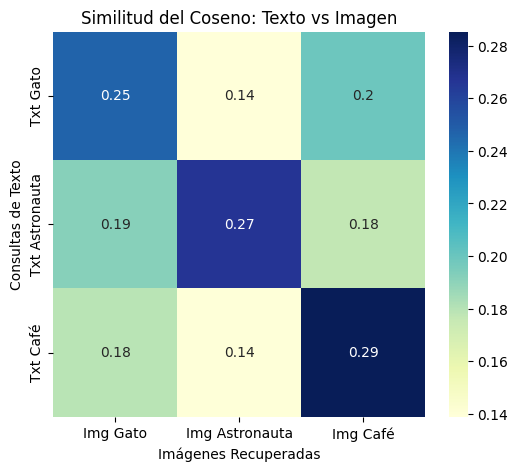

In [9]:
# Calcular similitud del coseno entre los embeddings de texto y de imagen
similarity_matrix = cosine_similarity(text_embeds.numpy(), image_embeds.numpy())

# Visualizar la matriz con Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(
    similarity_matrix, 
    annot=True, 
    cmap="YlGnBu", 
    xticklabels=["Img Gato", "Img Astronauta", "Img Café"],
    yticklabels=["Txt Gato", "Txt Astronauta", "Txt Café"]
)
plt.title("Similitud del Coseno: Texto vs Imagen")
plt.ylabel("Consultas de Texto")
plt.xlabel("Imágenes Recuperadas")
plt.show()